In [1]:
# ===== Librairies principales =====
import numpy as np
import pandas as pd
import cv2
import os
import matplotlib.pyplot as plt

# ===== Machine Learning =====
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ===== Gestion des warnings =====
import warnings
warnings.filterwarnings("ignore")

In [1]:
import os
import numpy as np

def print_folders(directory, depth=0):
    if depth == 2:  # stop recursion at depth 2
        return

    for folder in os.listdir(directory):

        folder_path = os.path.join(directory, folder)

        if os.path.isdir(folder_path):

            print(folder_path)
            print_folders(folder_path, depth=depth+1)


dataset_path = r"C:\Users\joz3ph\Documents\ESTSB\python\projet\datasetcopy\trainandtest"

print_folders(dataset_path)

C:\Users\joz3ph\Documents\ESTSB\python\projet\datasetcopy\trainandtest\test
C:\Users\joz3ph\Documents\ESTSB\python\projet\datasetcopy\trainandtest\test\Accessories
C:\Users\joz3ph\Documents\ESTSB\python\projet\datasetcopy\trainandtest\test\Clothes
C:\Users\joz3ph\Documents\ESTSB\python\projet\datasetcopy\trainandtest\test\Cosmetic
C:\Users\joz3ph\Documents\ESTSB\python\projet\datasetcopy\trainandtest\test\Electronic
C:\Users\joz3ph\Documents\ESTSB\python\projet\datasetcopy\trainandtest\test\Food
C:\Users\joz3ph\Documents\ESTSB\python\projet\datasetcopy\trainandtest\test\Institution
C:\Users\joz3ph\Documents\ESTSB\python\projet\datasetcopy\trainandtest\test\Leisure
C:\Users\joz3ph\Documents\ESTSB\python\projet\datasetcopy\trainandtest\test\Medical
C:\Users\joz3ph\Documents\ESTSB\python\projet\datasetcopy\trainandtest\test\Necessities
C:\Users\joz3ph\Documents\ESTSB\python\projet\datasetcopy\trainandtest\test\Transportation
C:\Users\joz3ph\Documents\ESTSB\python\projet\datasetcopy\traina

In [2]:
import os
import matplotlib.pyplot as plt
import numpy as np

directory_path = r"C:\Users\joz3ph\Documents\ESTSB\python\projet\datasetcopy\trainandtest"

train_data_path = os.path.join(directory_path, "train")
test_data_path = os.path.join(directory_path, "test")

class_names = os.listdir(train_data_path)

print("Classes:", class_names)

Classes: ['Accessories', 'Clothes', 'Cosmetic', 'Electronic', 'Food', 'Institution', 'Leisure', 'Medical', 'Necessities', 'Transportation']


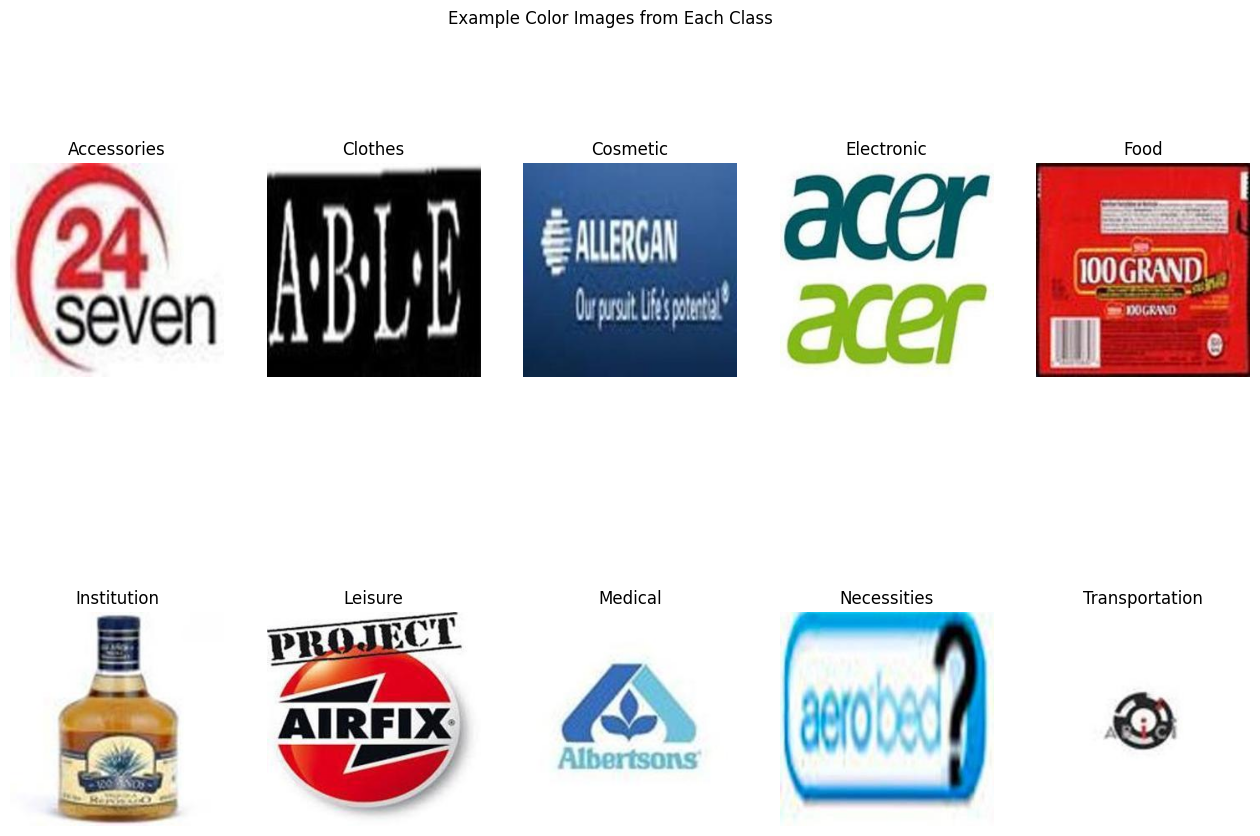

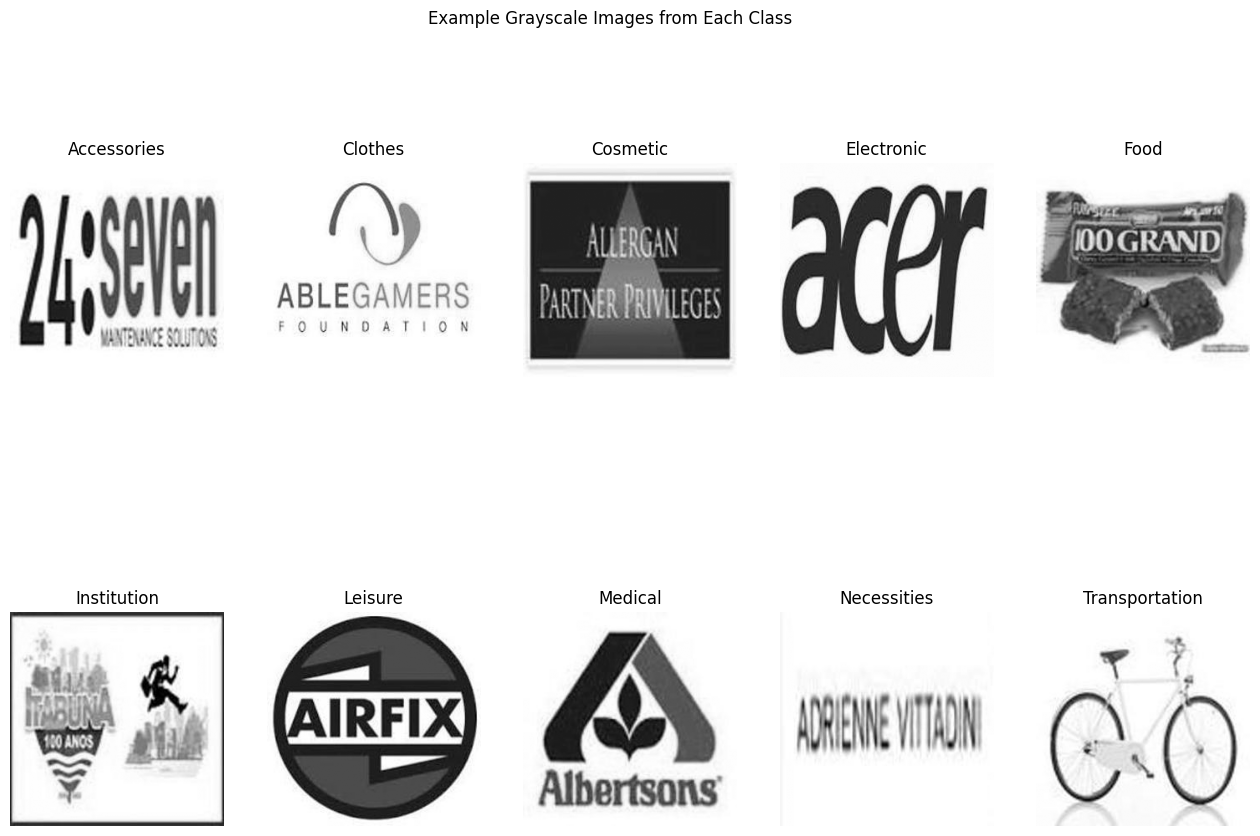

In [3]:
# Plot some example color images
fig, axs = plt.subplots(2, 5, figsize=(16, 10))

for i, class_name in enumerate(class_names[:10]):

    class_dir = os.path.join(train_data_path, class_name)
    img_names = []

    for subdir in os.listdir(class_dir):

        subdir_path = os.path.join(class_dir, subdir)

        if os.path.isdir(subdir_path):

            img_names += [
                os.path.join(subdir_path, img_name)
                for img_name in os.listdir(subdir_path)
                if img_name.lower().endswith((".jpg", ".jpeg", ".png")) and not img_name.startswith(".")
            ][:5]

    if len(img_names) < 5:
        continue

    for j, img_path in enumerate(img_names[:5]):

        img = plt.imread(img_path)

        axs[i//5, i%5].imshow(img)
        axs[i//5, i%5].axis('off')

        if j == 0:
            axs[i//5, i%5].set_title(class_name)

plt.suptitle("Example Color Images from Each Class")
plt.subplots_adjust(hspace=0.4)
plt.show()



# Plot some example grayscale images
fig, axs = plt.subplots(2, 5, figsize=(16, 10))

for i, class_name in enumerate(class_names[:10]):

    class_dir = os.path.join(test_data_path, class_name)
    img_names = []

    for subdir in os.listdir(class_dir):

        subdir_path = os.path.join(class_dir, subdir)

        if os.path.isdir(subdir_path):

            img_names += [
                os.path.join(subdir_path, img_name)
                for img_name in os.listdir(subdir_path)
                if img_name.lower().endswith((".jpg", ".jpeg", ".png")) and not img_name.startswith(".")
            ][:5]

    if len(img_names) < 5:
        continue

    for j, img_path in enumerate(img_names[:5]):

        img = plt.imread(img_path)

        img_gray = 0.2989 * img[:,:,0] + 0.5870 * img[:,:,1] + 0.1140 * img[:,:,2]

        axs[i//5, i%5].imshow(img_gray, cmap='gray')
        axs[i//5, i%5].axis('off')

        if j == 0:
            axs[i//5, i%5].set_title(class_name)

plt.suptitle("Example Grayscale Images from Each Class")
plt.subplots_adjust(hspace=0.4)
plt.show()

In [4]:
import cv2

sift = cv2.SIFT_create()
train_descriptors = []

MAX_PER_CLASS = 300

img_paths = []
for class_name in class_names:
    class_imgs = [
        os.path.join(train_data_path, class_name, subdir, img_name)
        for subdir in os.listdir(os.path.join(train_data_path, class_name))
        if os.path.isdir(os.path.join(train_data_path, class_name, subdir))
        for img_name in os.listdir(os.path.join(train_data_path, class_name, subdir))
        if img_name.lower().endswith((".jpg", ".png", ".jpeg"))
    ]
    img_paths += class_imgs[:MAX_PER_CLASS]

print(f"Total images : {len(img_paths)}")

for img_path in img_paths:
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.resize(img, (64,64))        # 👈 ajouté
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.equalizeHist(gray)            # 👈 ajouté
    _, descriptors = sift.detectAndCompute(gray, None)
    if descriptors is not None:
        train_descriptors.append(descriptors)

train_descriptors = np.vstack(train_descriptors)
print("Nombre total de descripteurs :", train_descriptors.shape)

Total images : 3000
Nombre total de descripteurs : (134366, 128)


In [14]:
from sklearn.cluster import KMeans

K = 2000  # Nombre de visual words

print(f"Construction du dictionnaire visuel avec K={K} clusters...")
kmeans = KMeans(n_clusters=K, random_state=42, n_init=3)
kmeans.fit(train_descriptors)
print("Dictionnaire visuel construit ✓")

Construction du dictionnaire visuel avec K=2000 clusters...
Dictionnaire visuel construit ✓


In [6]:
from sklearn.preprocessing import normalize

def encode_bow(descriptors, kmeans, K):
    histogram = np.zeros(K)
    if descriptors is not None:
        words = kmeans.predict(descriptors)
        for w in words:
            histogram[w] += 1
    return histogram

X_train, y_train = [], []

for img_path in img_paths:
    img = cv2.imread(img_path)
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, descriptors = sift.detectAndCompute(gray, None)
    bow_vector = encode_bow(descriptors, kmeans, K)
    X_train.append(bow_vector)
    class_name = os.path.relpath(img_path, train_data_path).split(os.sep)[0]
    y_train.append(class_name)

X_train = normalize(np.array(X_train))
y_train = np.array(y_train)

print(f"X_train shape : {X_train.shape}")
print(f"Nombre de classes : {len(np.unique(y_train))}")

X_train shape : (3000, 2000)
Nombre de classes : 10


In [7]:
MAX_PER_CLASS_TEST = 300 # 20 images de test par classe

test_img_paths = []
for class_name in class_names:
    class_imgs = [
        os.path.join(test_data_path, class_name, subdir, img_name)
        for subdir in os.listdir(os.path.join(test_data_path, class_name))
        if os.path.isdir(os.path.join(test_data_path, class_name, subdir))
        for img_name in os.listdir(os.path.join(test_data_path, class_name, subdir))
        if img_name.lower().endswith((".jpg", ".png", ".jpeg"))
    ]
    test_img_paths += class_imgs[:MAX_PER_CLASS_TEST]

print(f"Total images test : {len(test_img_paths)}")  # doit afficher 200

X_test, y_test = [], []

for img_path in test_img_paths:
    img = cv2.imread(img_path)
    if img is None:
        continue
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, descriptors = sift.detectAndCompute(gray, None)
    bow_vector = encode_bow(descriptors, kmeans, K)
    X_test.append(bow_vector)
    class_name = os.path.relpath(img_path, test_data_path).split(os.sep)[0]
    y_test.append(class_name)

X_test = normalize(np.array(X_test))
y_test = np.array(y_test)

print(f"X_test shape  : {X_test.shape}")
print(f"Nombre de classes : {len(np.unique(y_test))}")  # doit afficher 10

Total images test : 3000
X_test shape  : (3000, 2000)
Nombre de classes : 10


In [8]:
from sklearn.svm import SVC

print("Entraînement du SVM...")
svm = SVC(kernel='rbf', C=10, gamma='scale', decision_function_shape='ovr')
svm.fit(X_train, y_train)
print("SVM entraîné ✓")

Entraînement du SVM...
SVM entraîné ✓


In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = svm.predict(X_test)

classes_presentes = np.unique(y_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy : {accuracy * 100:.2f}%")

print("\nClassification Report :")
print(classification_report(y_test, y_pred, target_names=classes_presentes))

cm = confusion_matrix(y_test, y_pred)
print("Matrice de confusion :")
print(cm)

Accuracy : 42.73%

Classification Report :
                precision    recall  f1-score   support

   Accessories       0.37      0.41      0.39       300
       Clothes       0.33      0.45      0.38       300
      Cosmetic       0.34      0.44      0.39       300
    Electronic       0.52      0.43      0.47       300
          Food       0.51      0.48      0.49       300
   Institution       0.53      0.55      0.54       300
       Leisure       0.43      0.29      0.35       300
       Medical       0.52      0.39      0.44       300
   Necessities       0.36      0.41      0.38       300
Transportation       0.48      0.43      0.46       300

      accuracy                           0.43      3000
     macro avg       0.44      0.43      0.43      3000
  weighted avg       0.44      0.43      0.43      3000

Matrice de confusion :
[[122  33  51   7   5   5   9  13  37  18]
 [ 22 134  29  27  14  15  10  12  24  13]
 [ 17  19 133   5  24  19  12  19  37  15]
 [ 35  29  34 129 

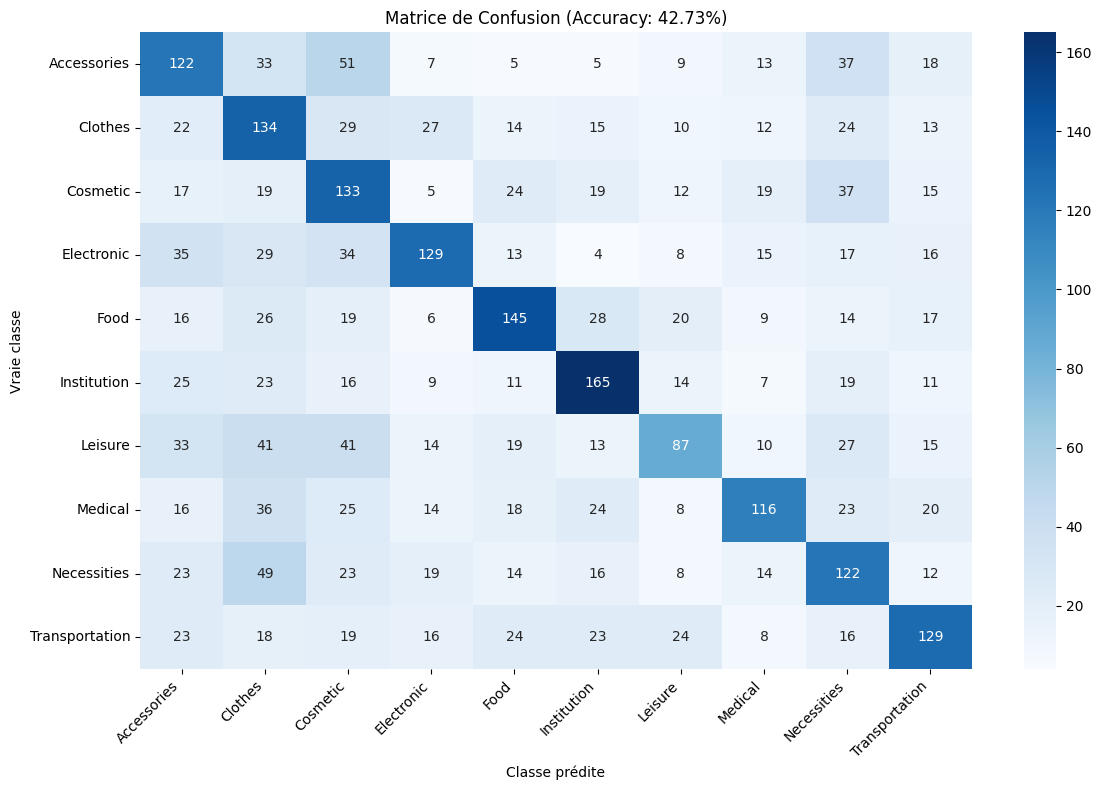

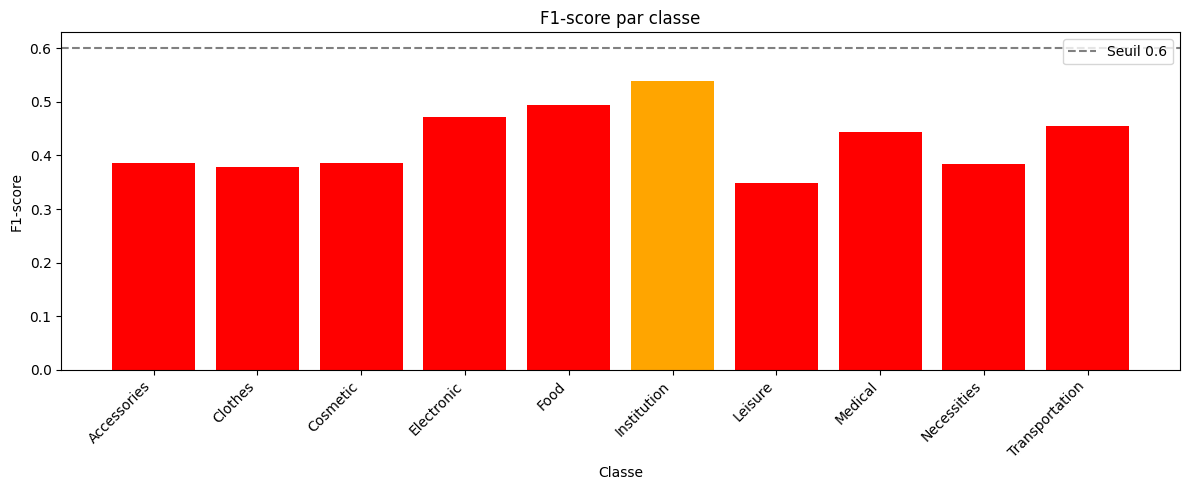

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
classes_presentes = np.unique(y_test) 

# Matrice de confusion
plt.figure(figsize=(12, 8))
sns.heatmap(cm, 
            annot=True, 
            fmt='d', 
            cmap='Blues',
            xticklabels=classes_presentes,
            yticklabels=classes_presentes)
plt.title(f'Matrice de Confusion (Accuracy: {accuracy*100:.2f}%)')
plt.ylabel('Vraie classe')
plt.xlabel('Classe prédite')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# F1-score par classe
from sklearn.metrics import f1_score
f1_scores = f1_score(y_test, y_pred, average=None, labels=classes_presentes)

plt.figure(figsize=(12, 5))
bars = plt.bar(classes_presentes, f1_scores, color=['green' if f > 0.7 else 'orange' if f > 0.5 else 'red' for f in f1_scores])
plt.title('F1-score par classe')
plt.xlabel('Classe')
plt.ylabel('F1-score')
plt.xticks(rotation=45, ha='right')
plt.axhline(y=0.6, color='gray', linestyle='--', label='Seuil 0.6')
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
def predict_logo(img_path):
    # Charger l'image
    img = cv2.imread(img_path)
    if img is None:
        print("Image introuvable !")
        return
    
    # Extraire SIFT
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, descriptors = sift.detectAndCompute(gray, None)
    
    if descriptors is None:
        print("Aucun descripteur trouvé !")
        return
    
    # Encoder en BoW
    bow_vector = encode_bow(descriptors, kmeans, K)
    bow_vector = normalize(bow_vector.reshape(1, -1))
    
    # Prédiction KNN
    prediction = knn.predict(bow_vector)[0]
    probas = knn.predict_proba(bow_vector)[0]
    confidence = max(probas) * 100
    
    # Affichage
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f'Prédiction : {prediction}\nConfiance : {confidence:.1f}%', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    print(f"Logo détecté : {prediction}")
    print(f"Confiance    : {confidence:.1f}%")

# ─── Tester sur une image ───
img_test_path = r"C:\Users\joz3ph\Documents\ESTSB\python\projet\datasetcopy\trainandtest\test\Food\McDonald's\00001.jpg"
predict_logo(img_test_path)

Image introuvable !


In [12]:
print("=" * 55)
print("        RÉSUMÉ DU PROJET - RECONNAISSANCE DE LOGOS")
print("=" * 55)

print(f"""
DATASET
   Dataset      : Logo-2K+
   Classes      : {len(classes_presentes)} categories
   Train        : {len(img_paths)} images ({MAX_PER_CLASS} par classe)
   Test         : {len(test_img_paths)} images ({MAX_PER_CLASS_TEST} par classe)

EXTRACTION DE FEATURES
   Methode      : SIFT
   Descripteurs : {train_descriptors.shape[0]} au total
   Taille       : {train_descriptors.shape[1]} dimensions

DICTIONNAIRE VISUEL
   Methode      : MiniBatch K-Means
   Visual Words : K = {K}

CLASSIFICATION
   Modele       : SVM
   Kernel       : {svm.kernel}
   C            : {svm.C}
   Gamma        : {svm.gamma}

RESULTATS
   Accuracy           : {accuracy * 100:.2f}%
   Meilleure classe   : {classes_presentes[np.argmax(f1_scores)]} ({max(f1_scores)*100:.1f}% F1)
   Pire classe        : {classes_presentes[np.argmin(f1_scores)]} ({min(f1_scores)*100:.1f}% F1)
""")

print("=" * 55)

        RÉSUMÉ DU PROJET - RECONNAISSANCE DE LOGOS

DATASET
   Dataset      : Logo-2K+
   Classes      : 10 categories
   Train        : 3000 images (300 par classe)
   Test         : 3000 images (300 par classe)

EXTRACTION DE FEATURES
   Methode      : SIFT
   Descripteurs : 134366 au total
   Taille       : 128 dimensions

DICTIONNAIRE VISUEL
   Methode      : MiniBatch K-Means
   Visual Words : K = 2000

CLASSIFICATION
   Modele       : SVM
   Kernel       : rbf
   C            : 10
   Gamma        : scale

RESULTATS
   Accuracy           : 42.73%
   Meilleure classe   : Institution (53.9% F1)
   Pire classe        : Leisure (34.8% F1)



In [15]:
import pickle
import os

os.makedirs(r"C:\Users\joz3ph\Documents\ESTSB\python\projet\app\models", exist_ok=True)

pickle.dump(kmeans, open(r"C:\Users\joz3ph\Documents\ESTSB\python\projet\app\models\kmeans_svm.pkl", "wb"))
pickle.dump(svm, open(r"C:\Users\joz3ph\Documents\ESTSB\python\projet\app\models\svm.pkl", "wb"))

print("Modèles SVM sauvegardés ✓")

Modèles SVM sauvegardés ✓
